# Tests for Wiener-SVD Unfolding Tool

- Closure test for sanity check: only use MC stat (technically don't event need this)
- Fake data tests for testing robustness of interaction uncertainties: only use MC stat and GENIE syst --

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial

# local imports
import sys
sys.path.append('../../')
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.unfolding.wienersvd import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 

import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)

mc_n_split: 1
mc_tot_pot: 1.518e+19
Integrated flux: 2.452e+11
# of targets:  1.3251484770937053e+30
XSEC_UNIT is 0, setting to 1e-38
xsec unit:  1e-38


/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/../../analysis_village/numucc_1p0pi/constants.py:56: RuntimeWarning: overflow encountered in scalar multiply
  xsec_unit = 1 / (integrated_flux * NTARGETS)


In [3]:
save_result = False
save_fig = save_result

save_fig_base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "unfolding-fake_data_tests-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

# load dataframes

In [5]:
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"
n_max_concat = 3
mc_keys2load = ['hdr', 'mcnu', 'evt'] 

concat_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    chunk_tags=generate_tags("ad"),
    # df_tag="_sel_mup-geniewgts",
    df_tag="",
    keys2load=mc_keys2load,
    n_max_concat=n_max_concat,
    sub_dir="MC",
    sample_dir="BNB_cosmics/genie_wgts"
)

mc_hdr_df = concat_dfs['hdr']
mc_nu_df = concat_dfs['mcnu']
mc_evt_df = concat_dfs['evt']

Reading file with tag aa, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag ab, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag ac, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']


In [6]:
## total pot
mc_tot_pot = mc_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))

# target_pot = 1e20
target_pot = mc_tot_pot
mc_pot_scale = target_pot / mc_tot_pot
print("mc_pot_scale: %.3e" %(mc_pot_scale))

mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
mc_nu_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_nu_df))

mc_tot_pot: 4.562e+19
mc_pot_scale: 1.000e+00


# Choose variable

In [7]:
var_config = VariableConfig.tki_del_Tp()

# Systematic Uncertainties

In [ ]:
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"
mcstat_syst = np.load(file_dir + "/mcstat_syst_dict.npz")
flux_syst = np.load(file_dir + "/flux_syst_dict.npz")
g4_syst = np.load(file_dir + "/g4_syst_dict.npz")
cosmics_syst = np.load(file_dir + "/cosmics_syst_dict.npz")
genie_syst = np.load(file_dir + "/genie_syst_dict.npz")

file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10"
detvar_syst = np.load(file_dir + "/detvar_syst_dict.npz")

# flat uncertainties
pot_frac_unc = 0.01
ntargets_frac_unc = 0.01

FileNotFoundError: [Errno 2] No such file or directory: '/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10/detvar_syst_dict.npz'

NameError: name 'detvar_syst' is not defined

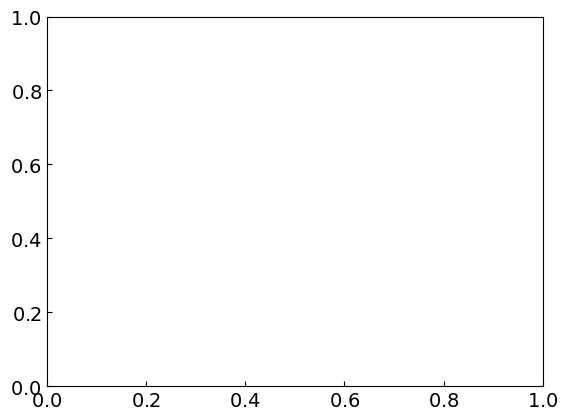

In [ ]:
fig, ax = plt.subplots()

frac_uncert_total = np.zeros(len(var_config.bin_centers))

# systs with covariance
systs      = [mcstat_syst, genie_syst, flux_syst, g4_syst, cosmics_syst, detvar_syst]
syst_names = ["MC stat.", "GENIE", "Flux", "G4", "Cosmics", "Detector"]
# flat systs
flat_systs = [pot_frac_unc, ntargets_frac_unc]
flat_syst_names = ["POT", "Ntargets"]

for syst_name, syst in zip(syst_names, systs):
    syst_uncert = np.sqrt(np.diag(syst[var_config.var_save_name]))
    frac_uncert_total += syst_uncert ** 2
    plt.hist(var_config.bin_centers, bins=var_config.bins, weights=syst_uncert * 1e2,   histtype="step", linewidth=2, label=syst_name)

for syst_name, syst in zip(flat_syst_names, flat_systs):
    syst_uncert = syst * np.ones(len(var_config.bin_centers))
    frac_uncert_total += syst_uncert ** 2
    plt.hist(var_config.bin_centers, bins=var_config.bins, weights=syst_uncert * 1e2,   histtype="step", linewidth=2, label=syst_name)

frac_uncert_total = np.sqrt(frac_uncert_total)
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=frac_uncert_total * 1e2,    histtype="step", linewidth=2, color="k",  label="Total")

plt.xlim(var_config.bins[0], var_config.bins[-1])
plt.ylim(0, max(frac_uncert_total*1e2) * 1.4)

plt.xlabel(var_config.var_labels[1])
plt.ylabel("Uncertainty [%]")
plt.legend(fontsize=11, ncol=3, loc="upper center")

plt.grid(which='major', linestyle='-', linewidth=0.7, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

if save_fig:
    plt.savefig("{}/uncertainty_breakdown-{}.pdf".format(save_fig_dir, var_config.var_save_name), bbox_inches='tight')
plt.show();

In [ ]:
syst

# Unfolding

In [8]:
# --- config for Wiener-SVD unfolding ---
C_type = 2
Norm_type = 0.5

## Closure test (Asimov data)
- use MC signal as fake data

In [9]:
# syst = np.sqrt(np.diag(mcstat_syst[var_config.var_save_name]))

In [10]:
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

unfolding_plotter = partial(
    overlay_hists,
    breakdown_type=breakdown_type,
    mc_df=mc_evt_df,
    data_df=mc_evt_df,
    intime_df=None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

In [11]:
pot_str = get_pot_str(mc_tot_pot)
plot_labels_hist = [var_config.var_labels[1], "Events / Bin (POT={})".format(pot_str), ""]

No intime cosmics provided
no syst provided
No syst provided


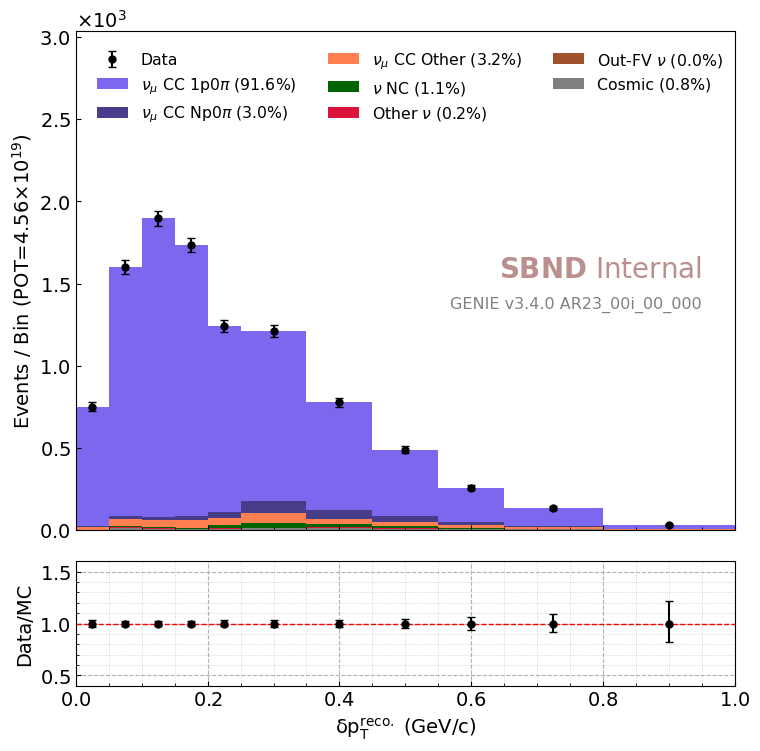

In [12]:
ret = unfolding_plotter(var_config=var_config,
                    plot_labels=plot_labels_hist,
                    syst=None,
                    save_name=path.join(save_fig_dir, "{}_{}.png".format(var_config.var_save_name, breakdown_type)))

Diagonal ratio: 0.67
True ratio: [0.75208513 0.62513966 0.64077177 0.64880052 0.62609497 0.65116764
 0.64335079 0.74681564]


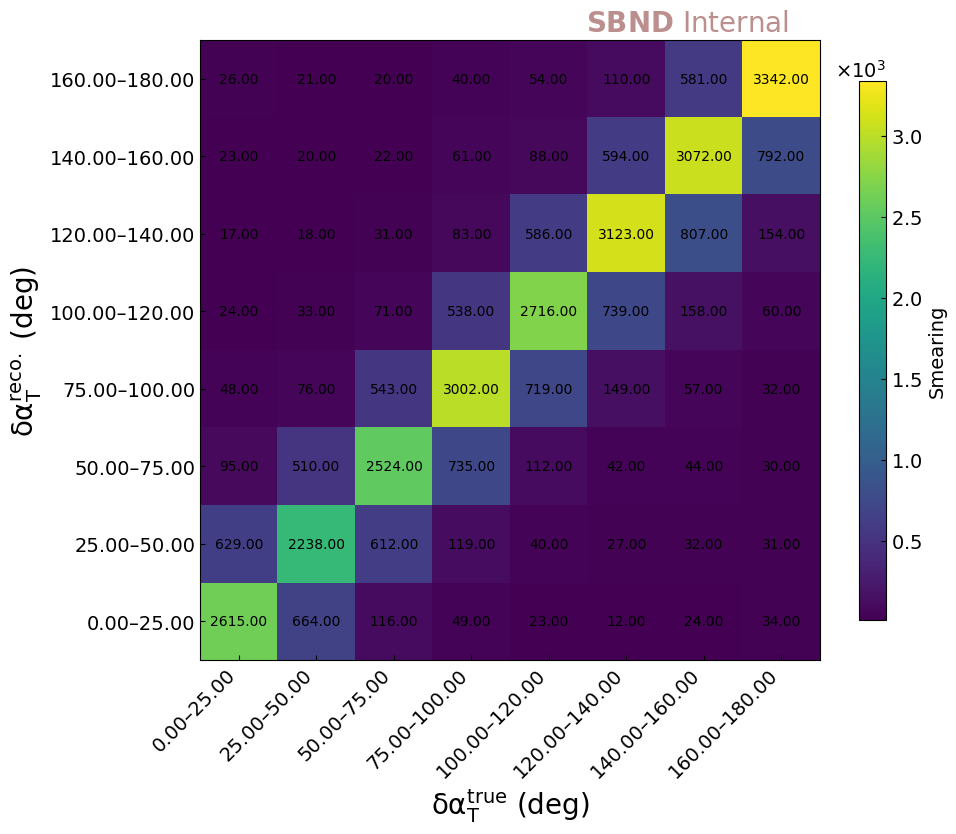

In [81]:
evtdf_signal = mc_evt_df[mc_evt_df.topo_categ == 1]
nudf_signal = mc_nu_df[mc_nu_df.topo_categ == 1]
ret = signal_hists(mc_evt_df, mc_nu_df, var_config, return_data=True, plot=False)

save_fig_name = "{}/{}-reco_vs_true".format(save_fig_dir, var_config.var_save_name)
reco_vs_true, _, _ = np.histogram2d(ret["var_sel_truth"], 
                                    ret["var_sel_reco"], 
                                    weights=ret["wgt_sel_reco"],
                                    bins=var_config.bins)

plot_heatmap(reco_vs_true, 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Smearing"],
             verbose=True,
             save_fig=save_fig, 
             save_name=save_fig_name)

Diagonal ratio: 0.66
True ratio: [0.73932711 0.60032189 0.61681329 0.64894077 0.62595068 0.64805976
 0.65753425 0.79685265]


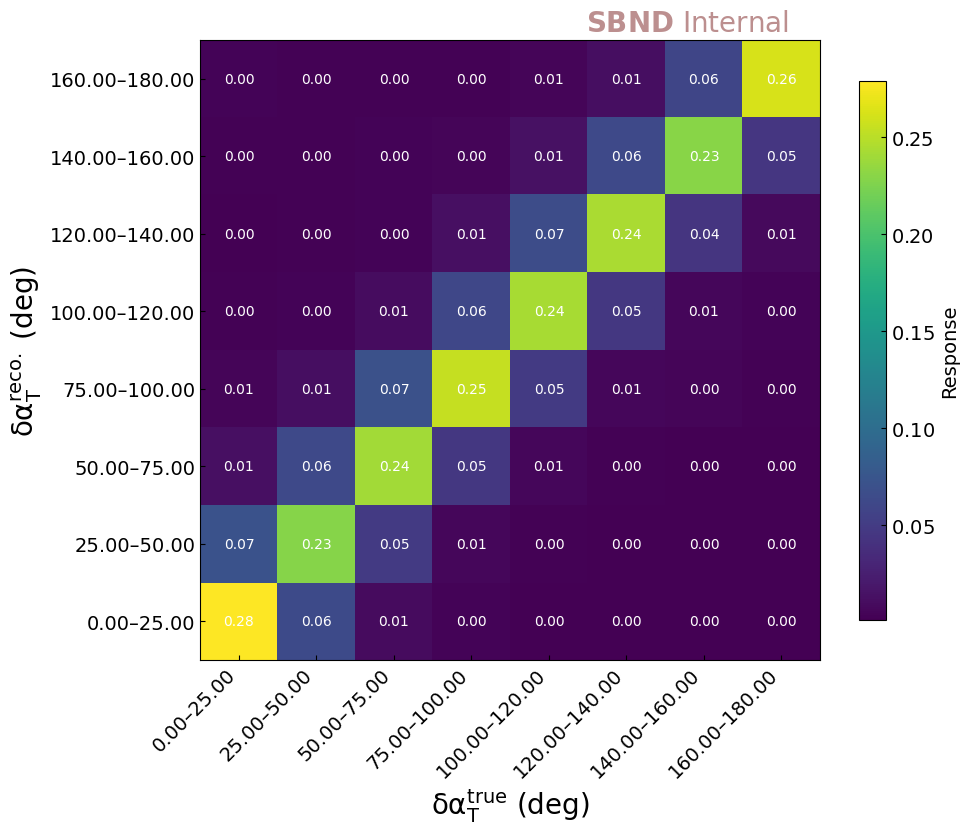

In [82]:
eff = ret["nevts_sel_truth"] / ret["nevts_allmc"]

save_fig_name = "{}/{}-response_matrix".format(save_fig_dir, var_config.var_save_name)
response = get_response_matrix(reco_vs_true, eff)

plot_heatmap(response, 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response"],
             save_fig=save_fig, 
             verbose=True,
             save_name=save_fig_name)


In [83]:
measured = ret["nevts_sel_reco"] * XSEC_UNIT 
model    = ret["nevts_allmc"] * XSEC_UNIT
Covariance = cov_from_fraccov(mcstat_syst[var_config.var_save_name], ret["nevts_sel_reco"]) * XSEC_UNIT**2
unfold = WienerSVD(response, model, measured, Covariance, C_type, Norm_type)
# print(unfold.keys())
# decomp_cov = Matrix_Decomp(model, unfold['SystUnfoldCov'])

KeyError: 'tki-del_alpha is not a file in the archive'

In [ ]:
models = {"SBND Baseline model": model}
save_name = "{}-closure_test_output.pdf".format(var_config.var_save_name)

plot_unfolded_result(unfold, 
                     measured, 
                     models, 
                     var_config,
                     save_fig=save_fig, 
                     save_name=save_name,
                     closure_test=True)

In [ ]:
save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "closure_test")
plot_heatmap(unfold["AddSmear"], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
             save_fig=save_fig, 
             save_name=save_fig_name)

## Fake Data Tests

- use alternate MC as fake data

In [ ]:
# use only stat unc and xsec unc for fake data tests
covariance_frac = genie_syst[var_config.var_save_name] + mcstat_syst[var_config.var_save_name]
covariance = cov_from_fraccov(covariance_frac, ret["nevts_sel_reco"]) * XSEC_UNIT**2

In [ ]:
unfolded_plot_labels = [var_config.var_labels[0], var_config.xsec_label]
smearmat_plot_labels = [var_config.var_labels[2], var_config.var_labels[1]]

In [ ]:
# # TODO: calculate this when making dfs
# mc_evt_df[("mu","pfp","trk","truth","p","dir","z")] = mc_evt_df.mu.pfp.trk.truth.p.genp.z / mc_evt_df.mu.pfp.trk.truth.p.totp

In [ ]:
from analysis_village.numucc_1p0pi.fake_data_test_configs import FakeDataWeights

fake_weight_obj = FakeDataWeights(mc_evt_df, mc_nu_df, var_config)

test_name = "mec_test"
scale_factor = 0.5
weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, scale_factor=scale_factor)

# test_name = "qe_test"
# scale_factor = 1.2
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, scale_factor=scale_factor)

# test_name = "np_test"
# Np_scale = 2
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, Np_scale=Np_scale)

# test_name = "sig_test"
# sig_scale = 1.2
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, sig_scale=sig_scale)

# test_name = "q2_test_alpha_0.3"
# alpha = 0.3
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, alpha=alpha)

# test_name = "costh_weight_scale_0.7"
# scale_factor = 0.7
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, scale_factor=scale_factor)

# test_name = "proton_P_tilt_alpha_0.3"
# alpha = 0.3
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, alpha=alpha)

# test_name = "bump_0.6_0.0015_0.001"
# bump_pos = 0.6
# bump_width = 0.0015
# bump_height = 0.001
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, bump_pos=bump_pos, bump_width=bump_width, bump_height=bump_height)

In [ ]:
nevts_fakedata_reco, _ = np.histogram(ret["var_allsel_reco"], bins=var_config.bins, weights=weights_fake_data)
nevts_nomdata_signal_truth, _ = np.histogram(ret["var_allmc"], bins=var_config.bins)
nevts_fakedata_signal_truth, _ = np.histogram(ret["var_allmc"], bins=var_config.bins, weights=weight_fakedata_signal_truth)

fig, ax = plt.subplots()
plt.hist(var_config.bin_centers, var_config.bins, weights=nevts_fakedata_reco, histtype="step", label="all selected events")
plt.hist(var_config.bin_centers, var_config.bins, weights=nevts_nomdata_signal_truth, histtype="step", label="nominal MC, all signal")
plt.hist(var_config.bin_centers, var_config.bins, weights=nevts_fakedata_signal_truth, histtype="step", label="alternative MC, all signal")
plt.legend()
plt.show();

In [ ]:
fakedata_evt_df = mc_evt_df.copy()
fakedata_evt_df["pot_weight"] *= weights_fake_data

In [ ]:
ret = overlay_hists(breakdown_type=breakdown_type,
                    mc_df=mc_evt_df,
                    data_df=fakedata_evt_df,
                    intime_df=None,
                    var_config=var_config,
                    plot_labels=plot_labels_hist,
                    ax_ylim_ratio=ax_ylim_ratio,
                    ratio=ratio,
                    syst=syst,
                    textloc=textloc,
                    approval=approval,
                    save_fig=save_fig, 
                    save_name=path.join(save_fig_dir, "{}_{}.png".format(var_config.var_save_name, breakdown_type)))

In [ ]:
measured = (ret["total_data"] - ret["total_mc_bkgd"]) * XSEC_UNIT
model = nevts_nomdata_signal_truth * XSEC_UNIT
unfold = WienerSVD(response, model, measured, covariance, C_type, Norm_type)

In [ ]:
models = {"SBND Baseline Model": model, 
          "Fake Data": nevts_fakedata_signal_truth * XSEC_UNIT}
save_name = "{}/{}-{}-unfolded_event_rates.pdf".format(save_fig_dir, test_name, var_config.var_save_name)
plot_unfolded_result(unfold, 
                     measured, 
                     models, 
                     var_config,
                     save_fig=save_fig, 
                     save_name=save_name,
                     closure_test=True)

In [ ]:
save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "closure_test")
plot_heatmap(unfold["AddSmear"], 
             var_config, 
             "",
             save_fig=save_fig, 
             save_fig_name=save_fig_name)

# Check distributions for fake data

## $Q^2$ reweight

In [ ]:
fake_weight_obj = FakeDataWeights(mc_evt_df, mc_nu_df, var_config)
Q2 = 2 * mc_evt_df.mc.E * mc_evt_df.mu.pfp.trk.truth.p.startE * (1 - mc_evt_df.mu.pfp.trk.truth.p.dir.z)
test_name = "q2_test_alpha_0.3"
alpha = 0.3
weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, alpha=alpha)

plt.hist(Q2, bins=var_config.bins, histtype="step", color="black", label="Nominal")
plt.hist(Q2, bins=var_config.bins, weights=weights_fake_data, histtype="step", color="red", label="Reweighted, $\\alpha=${}".format(alpha))
plt.xlabel("$Q^2$")
plt.ylabel("Events / Bin")
plt.legend()
if save_fig:
    plt.savefig("{}/Q2_reweight_{}.pdf".format(save_fig_dir, alpha), bbox_inches="tight")
plt.show();